In [1]:
import numpy as np
# from sympy import *
import matplotlib.pyplot as plt
import statsmodels.api as sm
import scipy.stats as stats
import seaborn as sns
# from random import sample # np.random.choice() is better
# init_printing(use_latex=True)

In [2]:
np.random.seed(15)
p = np.random.normal(100, 15, 10**6)

In [3]:
np.mean(p)

np.float64(100.00286655103558)

In [4]:
np.std(p)

np.float64(15.01008767195834)

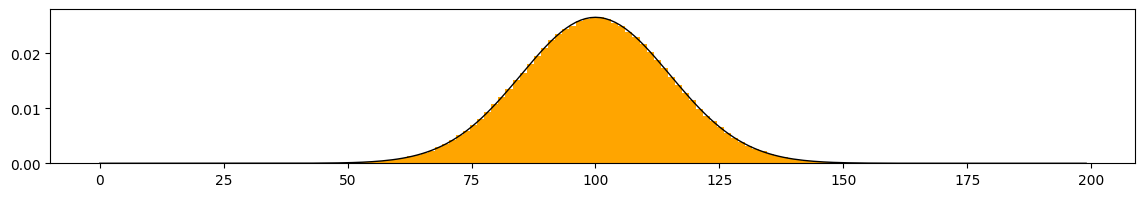

In [5]:
plt.figure(figsize = (14,2))
count, bins, ignored = plt.hist(p, 100, density=True, color='orange')
# sns.histplot(stats.zscore(p), element = 'step', kde = False).set(xticks=range(-5, 5, 1))
plt.plot(1/(np.std(p) * np.sqrt(2 * np.pi)) *
         np.exp( - (range(0,200) - np.mean(p))**2 / (2 * np.std(p)**2)),
         linewidth=1, color='black')
plt.show()

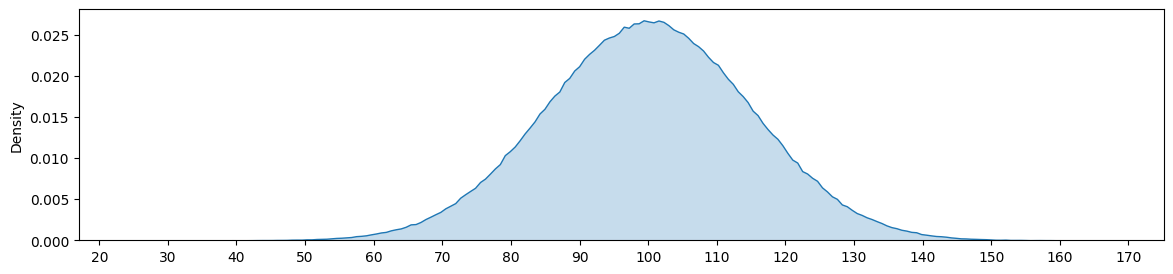

In [6]:
plt.figure(figsize = (14,3))
sns.kdeplot(p, fill = 1, bw_adjust=0.25).set(xticks=range(20, 180, 10))
plt.show()

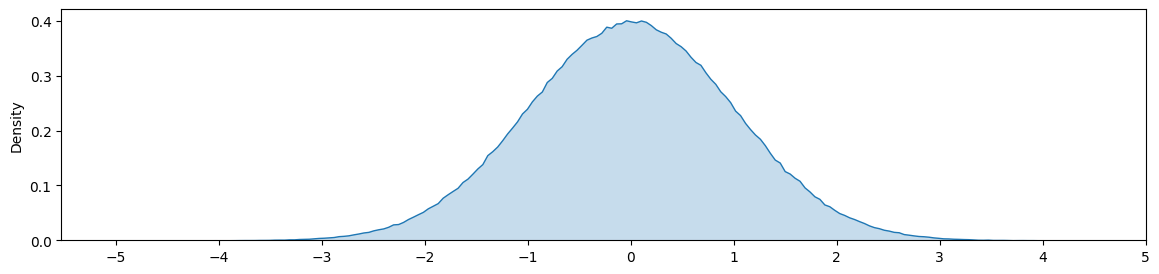

In [7]:
plt.figure(figsize = (14,3))
sns.kdeplot(stats.zscore(p), fill = 1, bw_adjust=0.25).set(xticks=range(-5, 6, 1))
plt.show()
# the area of a standard normal distribution is always 1
# the height at the mode (x=0) is (2*pi)^(-0.5) or 0.398942

In [8]:
p[39]

np.float64(130.7334814501253)

In [9]:
stats.zscore(p)[39]

np.float64(2.047330806501569)

In [10]:
((p-np.mean(p))/np.std(p))[39]

np.float64(2.047330806501569)

### cdf, cumulative density function
##### stats.norm.cdf calculates the area under the normal distribution that is left of a z-score
##### which is also the probability that a zscore is greater than another random one,
##### or the percent of random zscores that this value could be greater than.
##### outputs values between 0 and 1
##### it is actually sigmoid

In [11]:
stats.norm.cdf(2.04)

np.float64(0.9793248371339299)

In [12]:
stats.norm.cdf(stats.zscore(p)[39])

np.float64(0.9796871924461195)

In [13]:
stats.norm.cdf(1)-stats.norm.cdf(-1)   #68% of values fall within one standard deviation from the mean

np.float64(0.6826894921370859)

In [14]:
stats.norm.cdf(2)-stats.norm.cdf(-2)   #two stadard deviations

np.float64(0.9544997361036416)

In [15]:
stats.norm.cdf(3)-stats.norm.cdf(-3)   #three standard deviations

np.float64(0.9973002039367398)

In [16]:
stats.norm.cdf(4)-stats.norm.cdf(-4)   #four standard deviations

np.float64(0.9999366575163338)

In [17]:
stats.norm.cdf(5)-stats.norm.cdf(-5)   #five stadard deviations

np.float64(0.9999994266968562)

### ppf, percent point function
##### ppf is the inverse of cdf (0,1) -> z-score
##### it inputs an area under a standard normal distribution, from -inf 
##### or a probability that that a z-score is greater than a random one
##### or the percent of values that a z-score is greater than
##### it outputs a z-score, corresponding to that value
##### also used to calculate quantiles
##### takes inputs from 0 and 1

In [18]:
stats.norm.ppf(0.5)

np.float64(0.0)

In [19]:
stats.norm.ppf(0.05)

np.float64(-1.6448536269514729)

In [20]:
stats.norm.ppf(0.95)

np.float64(1.6448536269514722)

## Quantiles, percentiles, quartiles
##### quartiles and percentiles are subsets of quantiles
##### they are outputs of ppf, but it does not matter if they are z-scores or values

<Axes: >

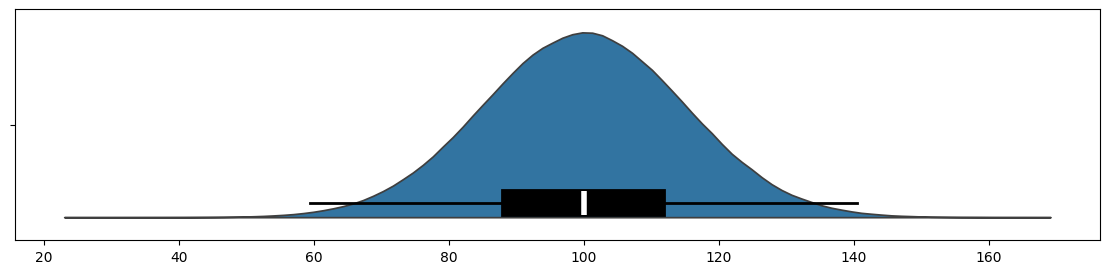

In [21]:
plt.subplots(figsize=(14,3))
sns.violinplot(x=p, split=True, gap=0, inner_kws=dict(box_width=20, whis_width=2, color="0")) #, inner="quart")
# violinplots display the median and quartiles 1 and 3

### Quartiles

In [22]:
stats.norm.ppf(0)

np.float64(-inf)

In [23]:
stats.norm.ppf(0.25)       #first quartile

np.float64(-0.6744897501960817)

In [24]:
stats.norm.ppf(0.5)        #median

np.float64(0.0)

In [25]:
stats.norm.ppf(0.75)       #third quartile

np.float64(0.6744897501960817)

In [26]:
stats.norm.cdf(0.6744) - stats.norm.cdf(-0.6744)    #interquartile range, 50% of values most close to the median

np.float64(0.49994295725411875)

In [27]:
stats.norm.ppf(1)

np.float64(inf)

### Percentiles
#### similar to quartiles, but for any percent
#### percents are the input z-scores/values are outputed
#### percentiles, as quartiles, are a specific type of quantiles

In [51]:
np.quantile(stats.zscore(p), [0,0.025,0.05,0.25,0.5,0.75,0.95,0.975,1])

array([-5.00266527e+00, -1.95896492e+00, -1.64536124e+00, -6.75161348e-01,
        2.70209776e-04,  6.75210769e-01,  1.64454522e+00,  1.95871877e+00,
        4.48065923e+00])

In [52]:
np.quantile(p, [0,0.025,0.05,0.25,0.5,0.75,0.95,0.975,1])       #these are specific values

array([ 24.91242224,  70.59863136,  75.30585008,  89.86863552,
       100.00692242, 110.13783939, 124.68763453, 129.40340698,
       167.25795446])

#### A 95% interval with two tails is actually from 0.025 to 0.975

In [53]:
stats.norm.ppf(0.025) # close but not exactly two standard deviations

np.float64(-1.9599639845400545)

In [54]:
stats.norm.ppf(0.975)

np.float64(1.959963984540054)

In [32]:
stats.norm.cdf(1.959963984540054) - stats.norm.cdf(-1.959963984540054)

np.float64(0.95)

### How to calculate quantiles
##### median

In [33]:
len(p)

1000000

In [34]:
np.median(p)

np.float64(100.00692242345916)

In [35]:
(np.sort(p)[499999] + np.sort(p)[500000])/2 # even number of values

np.float64(100.00692242345916)

##### quantiles

In [36]:
int((len(p)+1)*0.25)

250000

In [37]:
np.sort(p)[int((len(p)+1)*0.25)]

np.float64(89.86866375318286)

In [55]:
np.quantile(p,0.25)

np.float64(89.86863552287537)

### Percentiles

In [38]:
for i in range(1, 100):
    print(i/100, ': ', stats.norm.ppf(i/100), end=' ')

0.01 :  -2.3263478740408408 0.02 :  -2.053748910631823 0.03 :  -1.880793608151251 0.04 :  -1.75068607125217 0.05 :  -1.6448536269514729 0.06 :  -1.5547735945968535 0.07 :  -1.4757910281791706 0.08 :  -1.4050715603096329 0.09 :  -1.3407550336902165 0.1 :  -1.2815515655446004 0.11 :  -1.2265281200366098 0.12 :  -1.1749867920660904 0.13 :  -1.1263911290388007 0.14 :  -1.0803193408149558 0.15 :  -1.0364333894937898 0.16 :  -0.994457883209753 0.17 :  -0.9541652531461943 0.18 :  -0.915365087842814 0.19 :  -0.8778962950512288 0.2 :  -0.8416212335729142 0.21 :  -0.8064212470182404 0.22 :  -0.7721932141886848 0.23 :  -0.7388468491852137 0.24 :  -0.7063025628400874 0.25 :  -0.6744897501960817 0.26 :  -0.643345405392917 0.27 :  -0.6128129910166272 0.28 :  -0.5828415072712162 0.29 :  -0.5533847195556729 0.3 :  -0.5244005127080409 0.31 :  -0.4958503473474533 0.32 :  -0.46769879911450823 0.33 :  -0.4399131656732338 0.34 :  -0.41246312944140473 0.35 :  -0.38532046640756773 0.36 :  -0.3584587932511938

In [39]:
for i in range(1, 100):
    print(i, ': ', np.sort(p)[int((len(p)+1)*(i/100))], end=' ')

1 :  65.08018498093308 2 :  69.1956376815379 3 :  71.78605204912569 4 :  73.71221927865389 5 :  75.30587317718847 6 :  76.65924265990598 7 :  77.85204881897974 8 :  78.92117409700765 9 :  79.86654556980653 10 :  80.76016607975983 11 :  81.59063767948616 12 :  82.36168679642981 13 :  83.0917992864664 14 :  83.78617435920792 15 :  84.43568921452741 16 :  85.0613395234448 17 :  85.67219533953472 18 :  86.25352907779022 19 :  86.81397762557023 20 :  87.36832056111993 21 :  87.88984543592058 22 :  88.40586797386526 23 :  88.90665116322019 24 :  89.38992099644302 25 :  89.86866375318286 26 :  90.34216955780798 27 :  90.79526576660268 28 :  91.24377821644038 29 :  91.68202479891866 30 :  92.1157242757347 31 :  92.54859460371108 32 :  92.96670514288479 33 :  93.38772760658338 34 :  93.7951025019648 35 :  94.20362859646902 36 :  94.60948879016937 37 :  95.00951703970051 38 :  95.4129584425804 39 :  95.81160326461999 40 :  96.20424807809906 41 :  96.58706293501803 42 :  96.97449752923414 43 :  9

## Central limit theorem

In [40]:
a = [np.mean(np.random.choice(p, 100)) for i in range(10000)]
print('STD  = ', np.std(a), '\nVar  = ', np.var(a),
      '\nMean = ', np.mean(a), sep='')

STD  = 1.4909417854960212
Var  = 2.222907407738064
Mean = 100.02838052402922


In [41]:
a = [np.sum(np.random.choice(p, 100)) for i in range(1000)]
print('STD  = ', np.std(a), '\nVar  = ', np.var(a),
      '\nMean = ', np.mean(a), sep='')

STD  = 146.68225539071884
Var  = 21515.684046508068
Mean = 10000.923718601753


In [42]:
a = [np.mean(np.random.choice(100 * (p - 100.00286655103558) / 15.01008767195834, 10000)) for i in range(1000)]
print('STD  = ', np.std(a), '\nVar  = ', np.var(a),
      '\nMean = ', np.mean(a), sep='')
# statndardized form of CLT

STD  = 1.0377530085755222
Var  = 1.076931306807548
Mean = -0.04224953890660662


T distribution

In [43]:
stats.t.ppf(0.025, 39)

np.float64(-2.022690920036761)

In [44]:
stats.t.cdf(2.0227, 39) - stats.t.cdf(-2.0227, 39)

np.float64(0.9500009789068153)

Confidence intervals, Prediction intervals

In [91]:
n = 40
X = np.random.choice(p, n)
print('Mean = ', np.mean(X), '\nSTD  = ', np.std(X,ddof=1), sep='')

Mean = 94.61001255916486
STD  = 17.041529702949934


In [92]:
stats.norm.ppf(0.975)
# 0.975 percentile, 0.025 for -1.96
# -1.96 to 1.96 --- 95% of normal distribution area

np.float64(1.959963984540054)

##### Confidence and prediction intervals based on population STD and normal distribution qunatiles
###### population mean = sample mean +/- 1.96 * SE

In [93]:
print('CI: ',   np.mean(X), ' +/- ', stats.norm.ppf(0.975) * np.std(p)/(n**0.5),
      '\n=   ', np.mean(X) -         stats.norm.ppf(0.975) * np.std(p)/(n**0.5), ' --- ',
                np.mean(X) +         stats.norm.ppf(0.975) * np.std(p)/(n**0.5), sep='')
#               sample mean   +/-    0.975 quantile = 1.96 * pop. STD / n**0.5

CI: 94.61001255916486 +/- 4.65158888676786
=   89.958423672397 --- 99.26160144593271


In [94]:
print('PI: ',   np.mean(X), ' +/- ', stats.norm.ppf(0.975) * np.std(p) * ((n+1)/n)**0.5,
      '\n=   ', np.mean(X) -         stats.norm.ppf(0.975) * np.std(p) * ((n+1)/n)**0.5, ' --- ',
                np.mean(X) +         stats.norm.ppf(0.975) * np.std(p) * ((n+1)/n)**0.5, sep='')
#               sample mean   +/-    0.975 quantile = 1.96 * pop. STD  * ((n+1)/n)**0.5

PI: 94.61001255916486 +/- 29.78470154343657
=   64.82531101572829 --- 124.39471410260143


In [95]:
# If we use sample std instead, we use the t distribution, same quantiles, n-1 df
stats.t.ppf(0.975,n)

np.float64(2.0210753903062733)

In [96]:
print('CI: ',   np.mean(X), ' +/- ', stats.t.ppf(0.975,n-1) * np.std(X,ddof=1)/(n**0.5),
      '\n=   ', np.mean(X) -         stats.t.ppf(0.975,n-1) * np.std(X,ddof=1)/(n**0.5), ' --- ',
                np.mean(X) +         stats.t.ppf(0.975,n-1) * np.std(X,ddof=1)/(n**0.5), sep='')
#               sample mean   +/-    0.975 t quantile, dof  * sample STD      / n**0.5

CI: 94.61001255916486 +/- 5.450145606736221
=   89.15986695242864 --- 100.06015816590107


In [97]:
print('PI: ',   np.mean(X), ' +/- ', stats.t.ppf(0.975,n-1) * np.std(X,ddof=1)*((n+1)/n)**0.5,
      '\n=   ', np.mean(X) -         stats.t.ppf(0.975,n-1) * np.std(X,ddof=1)*((n+1)/n)**0.5, ' --- ',
                np.mean(X) +         stats.t.ppf(0.975,n-1) * np.std(X,ddof=1)*((n+1)/n)**0.5, sep='')
#               sample mean   +/-    0.975 t quantile, dof  * sample STD      *((n+1)/n)**0.5 

PI: 94.61001255916486 +/- 34.89795943203085
=   59.712053127134006 --- 129.50797199119572


In [142]:
stats.t.interval(confidence=0.95, df = 39, loc = np.mean(X), scale = stats.sem(X,ddof=1))

(np.float64(89.15986695242864), np.float64(100.06015816590107))

one sample t-test

In [ ]:
# Critical t value for a two-tailed t-test, alpha = 0.05
stats.t.ppf(0.975, df = n-1)

np.float64(2.0226909200367604)

In [ ]:
# t statistic
n ** 0.5 * ( np.mean(X) - 100 ) / np.std(X, ddof=1)

np.float64(-2.000364658554171)

In [ ]:
stats.t.cdf(-2.000364658554171, df = 39) * 2
# requires the t - score to be negative for a value centered arount 0.025 and not 0.975
# requires multiplying by 2 for a two tailed test

np.float64(0.05245801206914817)

In [ ]:
stats.t.sf(2.000364658554171, df=39) * 2
# more optimized for tail probabilities

np.float64(0.05245801206914817)

In [109]:
stats.ttest_1samp(X, popmean = 100)

TtestResult(statistic=np.float64(-2.000364658554171), pvalue=np.float64(0.05245801206914817), df=np.int64(39))

In [ ]:
# z statistic
n ** 0.5 * ( np.mean(X) - 100 ) / np.std(p)

np.float64(-2.271090915022926)

In [137]:
stats.norm.cdf(-1.96) * 2

np.float64(0.04999579029644087)